# Social Norm Stimuli Extraction (Study 2 – SSL)

This notebook extracts structured social norm examples from the Social-Chem-101 dataset to support synthetic social learning (SSL). The dataset covers a broad range of interpersonal scenarios drawn from sources like *dearabby*, *confessions*, *rocstories*, and *amitheasshole*.

Norms are represented through free-text rules-of-thumb (RoTs) grounded in everyday situations. These RoTs express judgments about social behavior, reflecting shared expectations about boundaries, roles, politeness, and group dynamics.

Annotations provide metadata on agreement levels, cultural pressure, moral framing, and character targeting. This structure enables filtering for examples with diverse viewpoints, competing norms, or clear attribution to specific actors.

The selection process emphasizes:
- Social relevance beyond general advice or abstract morality
- Involvement of identifiable characters or interpersonal roles
- Variation in cultural strength, agreement, and moral foundations
- Clear and interpretable rule-of-thumb phrasing

Filtered outputs serve as candidate SSL stimuli that model how social knowledge can be learned and reasoned over in context.


## Read and prepare the Social-Chem-101 dataset

The full dataset contains rule-of-thumb (RoT) annotations tied to free-text situations. Some fields include missing or incomplete values, so it's important to use a method that preserves nulls and avoids type coercion.


In [1]:
import pandas as pd

# Path to the raw Social-Chem-101 dataset
social_path = "../data/raw/social-chem-101.v1.0.tsv"

# Read as tab-separated values and preserve missing fields using convert_dtypes()
df_social = pd.read_csv(social_path, sep="\t").convert_dtypes()

# Check a few rows to verify the structure
df_social.sample(3)


,area,m,split,rot-agree,rot-categorization,rot-moral-foundations,rot-char-targeting,rot-bad,rot-judgment,action,...,action-char-involved,action-hypothetical,situation,situation-short-id,rot,rot-id,rot-worker-id,breakdown-worker-id,n-characters,characters
325893,dearabby,5,test-extra,3,social-norms|advice,loyalty-betrayal,char-1,0,It's bad,being divorced with children.,...,char-1,explicit,Ex-Wife Offers to Pay Child Support She Owes t...,dearabby/title/dearabby_2019_8_30_0_ex-wife-of...,It's bad to be divorced with children.,rot/dearabby/title/dearabby_2019_8_30_0_ex-wif...,101,127,3,narrator|Ex - Wife|Kids
203603,rocstories,1,train,4,advice,<NA>,char-1,0,good,Tending to a garden to mahe sure that the crop...,...,char-1,explicit,Henry was walking outside to tend to his garden.,rocstories/dc50860d-5bdd-48f0-9e07-841d0744b6f...,Tending to a garden makes sure that the crops ...,rot/rocstories/dc50860d-5bdd-48f0-9e07-841d074...,94,12,2,narrator|Henry
80568,confessions,1,test,3,social-norms,loyalty-betrayal,char-0,0,It's normal,liking your best friend's girlfriend.,...,char-0,explicit,I think love my best friends GF,reddit/confessions/7dpp1e,It's normal to like your best friend's girlfri...,rot/reddit/confessions/7dpp1e/3DYGAII7PONFAO9L...,100,125,3,narrator|my best friends GF|my best friends


In [2]:
# Show all column names to understand available annotations
print("Column Names:")
print(df_social.columns.tolist())

# Look at a few full records with all non-null fields
df_social.dropna(axis=0, how="any").sample(3).T


Column Names:
['area', 'm', 'split', 'rot-agree', 'rot-categorization', 'rot-moral-foundations', 'rot-char-targeting', 'rot-bad', 'rot-judgment', 'action', 'action-agency', 'action-moral-judgment', 'action-agree', 'action-legal', 'action-pressure', 'action-char-involved', 'action-hypothetical', 'situation', 'situation-short-id', 'rot', 'rot-id', 'rot-worker-id', 'breakdown-worker-id', 'n-characters', 'characters']


,334159,29136,31610
area,rocstories,amitheasshole,amitheasshole
m,5,1,1
split,test-extra,train,test
rot-agree,3,3,2
rot-categorization,advice,advice,advice
rot-moral-foundations,sanctity-degradation,care-harm,sanctity-degradation
rot-char-targeting,char-1,char-0,char-0
rot-bad,0,0,0
rot-judgment,it's encouraged,you should,should
action,setting a timer when you're cooking something ...,"If you are unhappy in your relationship, break...",always sleeping with your partner every night.


## Identify Key Fields for SSL-Relevant Norms

This section prepares the filtering logic for SSL-relevant RoTs. Compared to the AITA dataset, Social-Chem-101 includes structured annotations for character involvement, agreement, cultural pressure, moral framing, and legal context.

Filtering will focus on:

- **Clarity**: Remove RoTs marked as vague or low quality (`rot-bad`)
- **Social grounding**: Emphasize norms tied to specific actors (`rot-char-targeting`, `action-char-involved`)
- **Value diversity**: Retain norms with variation in agreement and pressure scores
- **Moral framing**: Include RoTs with specified foundations (`rot-moral-foundations`)

The next cell profiles key fields to guide this selection.


In [3]:
# Profile completeness and variability for relevant annotation fields
key_fields = [
    "rot-bad", "rot-char-targeting", "action-char-involved", "action-hypothetical",
    "rot-agree", "action-agree", "action-pressure", "action-moral-judgment",
    "rot-categorization", "rot-moral-foundations", "action-legal"
]

# Basic profiling: count non-nulls and number of unique values
profile = df_social[key_fields].agg(["count", "nunique"]).transpose()
profile.columns = ["non_null", "num_unique"]

# Compute null count and percentage separately
profile["null_count"] = df_social[key_fields].isna().sum()
profile["total"] = len(df_social)
profile["null_pct"] = profile["null_count"] / profile["total"]

# Sort by highest missingness
profile.sort_values("null_pct", ascending=False)


,non_null,num_unique,null_count,total,null_pct
rot-moral-foundations,278802,30,77120,355922,0.216677
action-hypothetical,288146,5,67776,355922,0.190424
action-pressure,309385,5,46537,355922,0.130751
action-char-involved,309481,7,46441,355922,0.130481
action-legal,310314,3,45608,355922,0.128140
action-moral-judgment,310707,5,45215,355922,0.127036
action-agree,311520,5,44402,355922,0.124752
rot-categorization,352876,15,3046,355922,0.008558
rot-char-targeting,354300,7,1622,355922,0.004557
rot-agree,354686,5,1236,355922,0.003473


## Filter for Social Stimuli with Grounded Moral Framing

This slice prioritizes RoTs that are (1) drawn from core sources of interpersonal context, (2) well-formed and character-targeted, (3) tied to interpretable situations, and (4) readable within two minutes.

Filtering includes:
- Source domain in `{dearabby, confessions, rocstories, amitheasshole}`
- RoTs not marked as bad
- Targeting of a specific character (not `"char-none"` or null)
- Annotated moral foundation
- Situation text between 10 and 476 words


In [4]:
# Define word count on the situation field
df_social["situation_wordcount"] = df_social["situation"].str.split().str.len()

# Apply initial filters
df_filtered = df_social[
    (df_social["area"].isin(["dearabby", "confessions", "rocstories", "amitheasshole"])) &
    (df_social["rot-bad"] == 0) &
    (df_social["rot-char-targeting"].notna()) &
    (df_social["rot-char-targeting"] != "char-none") &
    (df_social["rot-moral-foundations"].notna()) &
    (df_social["situation_wordcount"] > 10) &
    (df_social["situation_wordcount"] <= 476)
    ].copy()

print(f"Filtered stimuli count: {len(df_filtered):,}")
df_filtered[["area", "situation_wordcount", "rot", "situation"]].sample(5)


Filtered stimuli count: 102,350


,area,situation_wordcount,rot,situation
55592,amitheasshole,13,It's understandable to be uncomfortable with m...,refusing to meet with male fans after my shows...
165664,confessions,11,You shouldn't sleep with people that are just ...,I sleep with fat women soley for a feeling of ...
253933,rocstories,14,It's understandable if you're impressed when s...,He ended up getting up on his own and walked t...
224504,rocstories,14,it's good to be patient when someone is strugg...,She kindly told me how to spell the word I was...
164153,confessions,18,It's okay to be frustrated with your parents a...,I’m 16 but I can’t imagine the fact of living ...


## Score Judgment Entropy (Moral Diversity)

This section scores each rule-of-thumb based on the distribution of moral judgments. A higher entropy value suggests more interpretive ambiguity or disagreement about the morality of the action.

Judgments are bucketed from -2 (very bad) to +2 (very good). Shannon entropy is calculated over this distribution.


In [5]:
from scipy.stats import entropy

# Filter rows with non-null judgment values
judgment_counts = df_filtered["action-moral-judgment"].value_counts(dropna=True).sort_index()
total = judgment_counts.sum()
probs = judgment_counts / total

# Calculate Shannon entropy of the full judgment distribution
judgment_entropy = entropy(probs, base=2)

print("Shannon entropy of action-moral-judgment:", round(judgment_entropy, 3))
print("\nDistribution:")
print(judgment_counts)


Shannon entropy of action-moral-judgment: 1.873

Distribution:
action-moral-judgment
-2     5914
-1    30579
0     36927
1     18640
2      1611
Name: count, dtype: Int64


## Flesch-Kincaid Readability Filter

The Flesch-Kincaid Grade Level metric estimates U.S. school-grade readability based on sentence length and word complexity. RoTs above grade 8 are excluded to ensure clarity and ease of comprehension. This threshold aligns with communication standards for general adult audiences in the U.S. and supports efficient reading within a two-minute window.


In [6]:
import textstat

# Estimate grade-level readability using Flesch-Kincaid for RoTs only
df_filtered["fk_grade"] = df_filtered["rot"].apply(textstat.flesch_kincaid_grade)

# Keep RoTs at or below 8th-grade level
df_readable = df_filtered[df_filtered["fk_grade"] <= 8].copy()

# Preview examples with grade level
df_readable[["rot", "fk_grade", "situation"]].sample(5)


,rot,fk_grade,situation
153395,You shouldn't say racist slurs to people.,3.997143,Today I heard a racial slur from a coworker an...
109907,It's rude to ghost a longtime friend.,0.625714,I'm ghosting my longtime friend out of spite a...
152446,People will be annoyed with you if you insist ...,6.137500,The only reason I want a new phone is so I cou...
51451,It's good to care about your friends.,0.625714,"""going behind my friends back"" because I was w..."
156696,It's okay to feel frustrated when people say y...,4.790909,I hate when people don’t pronounce my name cor...


## Stratify by Foundation, Pressure, and Source Domain

Coverage is evaluated across moral foundations, cultural pressure levels, and narrative source. This ensures that selected RoTs reflect a range of perspectives, social contexts, and cultural expectations.

Distributions below can inform balanced sampling or quota design.


In [7]:
# Count distributions across stratification fields
foundation_counts = df_readable["rot-moral-foundations"].value_counts()
pressure_counts = df_readable["action-pressure"].value_counts()
area_counts = df_readable["area"].value_counts()

print("Moral Foundations:\n", foundation_counts, "\n")
print("Cultural Pressure:\n", pressure_counts, "\n")
print("Source Domains:\n", area_counts)


Moral Foundations:
 rot-moral-foundations
care-harm                                                                34884
fairness-cheating                                                        12160
loyalty-betrayal                                                         10399
care-harm|loyalty-betrayal                                                6381
authority-subversion                                                      6119
sanctity-degradation                                                      4235
care-harm|fairness-cheating                                               3400
care-harm|authority-subversion                                            2514
fairness-cheating|loyalty-betrayal                                        1905
care-harm|sanctity-degradation                                            1860
fairness-cheating|authority-subversion                                    1207
loyalty-betrayal|authority-subversion                                      648
fairness-c

## Visualize Coverage Across Foundations, Pressure, and Source

Visual summaries below illustrate coverage across key annotation axes. These patterns guide balanced sampling and help surface underrepresented categories.


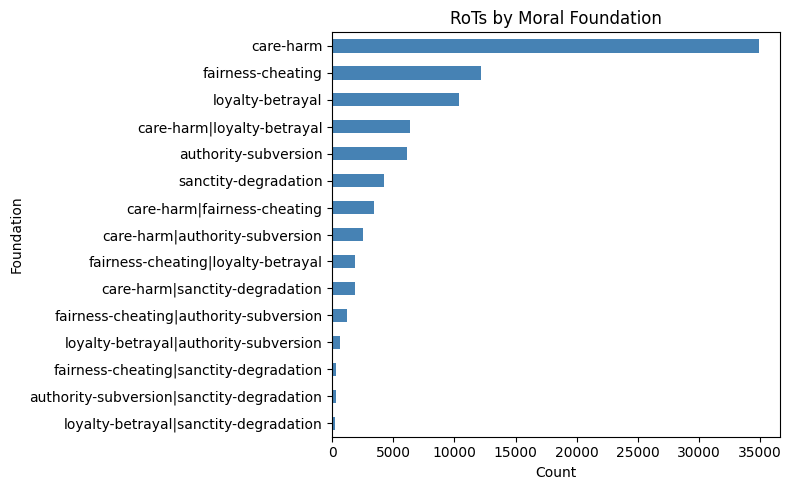

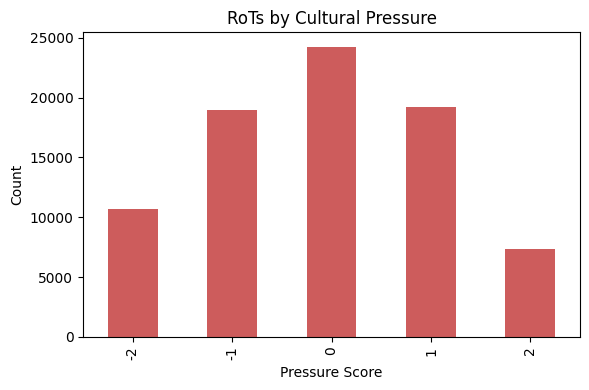

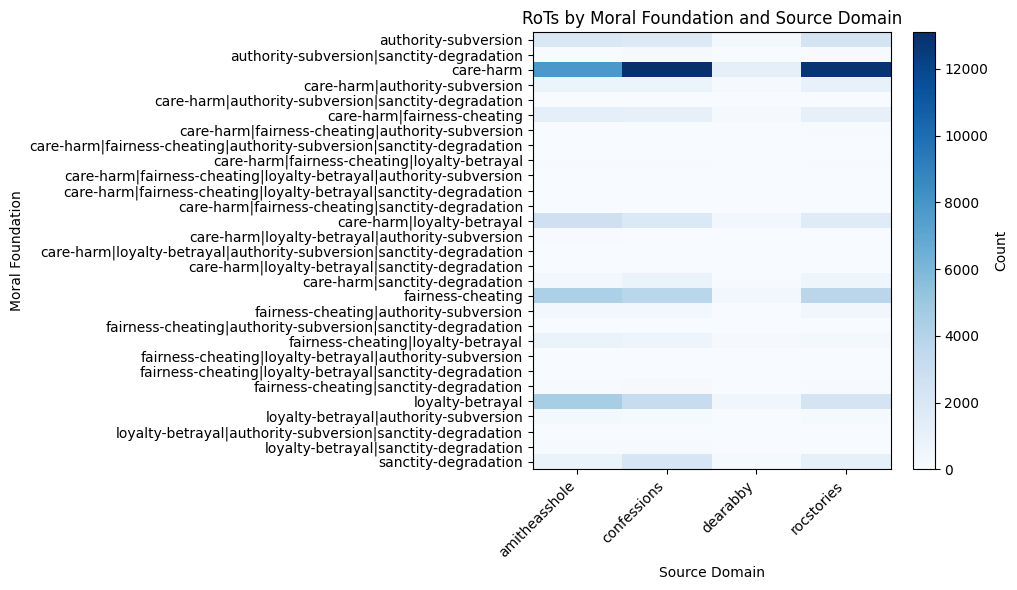

In [8]:
import matplotlib.pyplot as plt

# Set global style
plt.style.use("default")
plt.rcParams.update({"axes.titlesize": 12, "xtick.labelsize": 10, "ytick.labelsize": 10})

# 1. Moral foundations (horizontal bar)
df_readable["rot-moral-foundations"].value_counts().head(15).sort_values().plot(
    kind="barh", figsize=(8, 5), color="steelblue"
)
plt.title("RoTs by Moral Foundation")
plt.xlabel("Count")
plt.ylabel("Foundation")
plt.tight_layout()
plt.show()

# 2. Cultural pressure (keep vertical)
df_readable["action-pressure"].value_counts().sort_index().plot(
    kind="bar", figsize=(6, 4), color="indianred"
)
plt.title("RoTs by Cultural Pressure")
plt.xlabel("Pressure Score")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

# 3. Heatmap with foundations on Y-axis, areas on X-axis
cross = df_readable.pivot_table(
    index="rot-moral-foundations", columns="area", aggfunc="size", fill_value=0
)

plt.figure(figsize=(10, 6))
plt.imshow(cross, aspect="auto", cmap="Blues")
plt.title("RoTs by Moral Foundation and Source Domain")
plt.ylabel("Moral Foundation")
plt.xlabel("Source Domain")
plt.xticks(ticks=range(len(cross.columns)), labels=cross.columns, rotation=45, ha="right")
plt.yticks(ticks=range(len(cross.index)), labels=cross.index)
plt.colorbar(label="Count")
plt.tight_layout()
plt.show()


### Interpretation for SSL Stimuli Design

These patterns confirm that the filtered dataset supports Study 2 goals. RoTs span multiple moral foundations, with especially strong representation of care, fairness, and loyalty norms. Cultural pressure scores vary across the full spectrum, enabling selection of both consensual and contested social expectations.

Coverage across narrative domains shows that each source contributes distinct but overlapping moral content. This ensures that stimuli can be drawn from diverse framing contexts while preserving balance across moral categories. The filtered dataset offers sufficient interpretive ambiguity, interpersonal grounding, and structural clarity for SSL task construction.


In [9]:
# Final export: SSL-ready stimuli from Social-Chem-101
output_path = "../data/clean/social_ssl_filtered.csv"
df_readable.to_csv(output_path, index=False)
print(f"Exported {len(df_readable):,} examples to {output_path}")


Exported 87,335 examples to ../data/clean/social_ssl_filtered.csv


### Final Export for SSL Task Design

The exported dataset provides a curated set of rule-of-thumb stimuli for synthetic social learning (SSL) experiments. Each entry reflects a clear social or moral norm embedded in an interpersonal situation, with structured metadata on cultural pressure, moral framing, character roles, and readability.

This file provides the candidate stimuli for Study 2, which investigates how humans interpret, adopt, and transmit social knowledge generated or selected by AI systems. By balancing moral diversity, source framing, and accessibility, the export supports controlled variation in stimulus design. The selected examples are intended to evoke judgment, perspective-taking, and reasoning about social norms across a range of everyday scenarios.
